In [1]:
import os
os.environ['MPLCONFIGDIR'] = "/mnt/storage6/grace/plt_temp/"
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import xarray as xr
import netCDF4 as nc
from netCDF4 import Dataset
import scipy as sp

import datetime
import cftime
import time

import gsw

In [2]:
ds_t4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2018m05d25_gridT.nc")
ds_t12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2018m05d25_gridT.nc")

In [7]:
def make_land_mask(ds, inds):
    return np.ma.make_mask(ds['vosaline'][0,0,inds[0]:inds[1], inds[2]:inds[3]] != 0)

def isopycnal_interp(ds, inds, isopycnal):
    try:
        s = gsw.SA_from_Sstar(ds['vosaline'] * (35.16504/35), 10.1325, ds.nav_lon_grid_T, ds.nav_lat_grid_T)
    except: 
        s = gsw.SA_from_Sstar(ds['vosaline'] * (35.16504/35), 10.1325, ds.nav_lon, ds.nav_lat)
        
    rho = gsw.sigma0(s, ds['votemper'])[0,:,inds[0]:inds[1], inds[2]:inds[3]]
    rho = np.where(rho > 0, rho, np.nan)

    iso = isopycnal
    residuals = rho - iso

    stacked_ones = np.vstack([residuals, np.ones((1, rho[0,:,:].shape[0], rho[0,:,:].shape[1]))])
    print(stacked_ones.shape)
    depths = np.stack([np.stack([ds.deptht] * rho[0,:,:].shape[0], axis=1)]*rho[0,:,:].shape[1], axis=2)
    print(depths.shape)
        
    schange = stacked_ones[:-1,:,:] * stacked_ones[1:,:,:]
    print(schange.shape)

    m_rho = np.ma.make_mask(schange < 0)
    m_rho1 = np.insert(m_rho, 0, np.zeros((rho[0,:,:].shape[0], rho[0,:,:].shape[1])).astype(bool), axis=0)[:-1,:,:]

    rho1 = np.nansum(np.where(m_rho, rho, np.nan), axis=0)
    rho2 = np.nansum(np.where(m_rho1, rho, np.nan), axis=0)
    print(rho2.shape)

    z1 = np.nansum(np.where(m_rho, depths, np.nan), axis=0)
    z2 = np.nansum(np.where(m_rho1, depths, np.nan), axis=0)
    print(z2.shape)

    zs2interp = np.stack([z1,z2], axis=0) #monotonically increasing down
    rhos2interp = np.stack([rho1,rho2], axis=0) #monotonically increasing down

    interp_outz = np.zeros((rho[0,:,:].shape[0], rho[0,:,:].shape[1]))
    print(interp_outz.shape)

    for x in range(rho[0,:,:].shape[0]):
        for y in range(rho[0,:,:].shape[1]):
            interp_outz[x,y] = np.interp(iso, rhos2interp[:,x,y], zs2interp[:,x,y])
            
    land_mask = make_land_mask(ds_t4, inds)
    print(land_mask.shape)

    return [m_rho, m_rho1, interp_outz, zs2interp, land_mask]


def isopycnal_proj(var_proj, inds, interprod):
    var = var_proj[0,:,inds[0]:inds[1], inds[2]:inds[3]]
    var1 = np.nansum(np.where(interprod[0], var, np.nan), axis=0)
    print(var1.shape)
    var2 = np.nansum(np.where(interprod[1], var, np.nan), axis=0)
    print(var2.shape)

    interp_vars = np.stack([var1,var2], axis=0)

    var_out = np.zeros((interprod[4].shape[0], interprod[4].shape[1]))
    print(var_out.shape)

    for x in range(interprod[0].shape[0]):
        for y in range(interprod[0].shape[1]):
            var_out[x,y] = np.interp(interprod[2][x,y], interprod[3][:,x,y], interp_vars[:,x,y])
        
    var_out = np.where(interprod[4], var_out, np.nan)

    return var_out
    

In [14]:
rho_goal = 27.8
interprods = isopycnal_interp(ds_t4, [250,450,150,375], rho_goal)

(51, 200, 225)
(50, 200, 225)
(50, 200, 225)
(200, 225)
(200, 225)
(200, 225)
(200, 225)


In [15]:
projection = isopycnal_proj(ds_t4['vosaline'], [250,450,150,375], interprods)

(200, 225)
(200, 225)
(200, 225)


In [24]:
inds = [250,450,150,375]

s = gsw.SA_from_Sstar(ds_t4['vosaline'] * (35.16504/35), 10.1325, ds_t4.nav_lon_grid_T, ds_t4.nav_lat_grid_T)
    
rho = gsw.sigma0(s, ds_t4['votemper'])[0,:,inds[0]:inds[1], inds[2]:inds[3]]
rho = np.where(rho > 0, rho, np.nan)

residuals = rho - rho_goal

stacked_ones = np.vstack([residuals, np.ones((1, rho[0,:,:].shape[0], rho[0,:,:].shape[1]))])
print(stacked_ones.shape)
depths = np.stack([np.stack([ds_t4.deptht] * rho[0,:,:].shape[0], axis=1)]*rho[0,:,:].shape[1], axis=2)
print(depths.shape)
    
schange = stacked_ones[:-1,:,:] * stacked_ones[1:,:,:]
print(schange.shape)

m_rho = np.ma.make_mask(schange < 0)
m_rho1 = np.insert(m_rho, 0, np.zeros((rho[0,:,:].shape[0], rho[0,:,:].shape[1])).astype(bool), axis=0)[:-1,:,:]

rho1 = np.nansum(np.where(m_rho, rho, np.nan), axis=0)
rho2 = np.nansum(np.where(m_rho1, rho, np.nan), axis=0)
print(rho2.shape)

z1 = np.nansum(np.where(m_rho, depths, np.nan), axis=0)
z2 = np.nansum(np.where(m_rho1, depths, np.nan), axis=0)
print(z2.shape)

zs2interp = np.stack([z1,z2], axis=0) #monotonically increasing down
rhos2interp = np.stack([rho1,rho2], axis=0) #monotonically increasing down

interp_outz = np.zeros((rho[0,:,:].shape[0], rho[0,:,:].shape[1]))
print(interp_outz.shape)

for x in range(rho[0,:,:].shape[0]):
    for y in range(rho[0,:,:].shape[1]):
        interp_outz[x,y] = np.interp(rho_goal, rhos2interp[:,x,y], zs2interp[:,x,y])
        
land_mask = make_land_mask(ds_t4, inds)
print(land_mask.shape)


(51, 200, 225)
(50, 200, 225)
(50, 200, 225)
(200, 225)
(200, 225)
(200, 225)
(200, 225)


In [36]:
zs2interp.shape

(2, 200, 225)

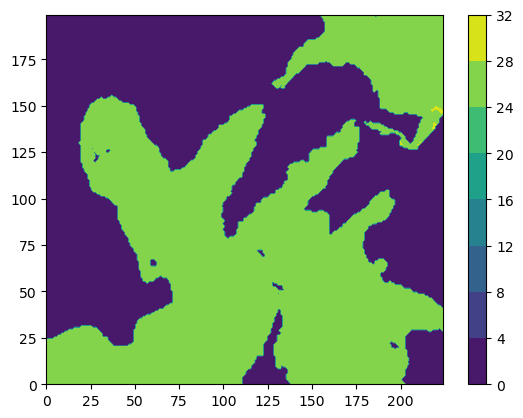

In [41]:
plt.contourf(rhos2interp[1])
plt.colorbar()

In [ ]:
def proj_test(var_proj, inds, interprod):
    var = var_proj[0,:,inds[0]:inds[1], inds[2]:inds[3]]
    var1 = np.nansum(np.where(interprod[0], var, np.nan), axis=0)
    print(var1.shape)
    var2 = np.nansum(np.where(interprod[1], var, np.nan), axis=0)
    print(var2.shape)

    interp_vars = np.stack([var1,var2], axis=0)

    var_out = np.zeros((interprod[4].shape[0], interprod[4].shape[1]))
    print(var_out.shape)

    for x in range(interprod[0].shape[0]):
        for y in range(interprod[0].shape[1]):
            var_out[x,y] = np.interp(interprod[2][x,y], interprod[3][:,x,y], interp_vars[:,x,y])
        
    var_out = np.where(interprod[4], var_out, np.nan)

    return var_out

Text(0.5, 0, 'Longitude')

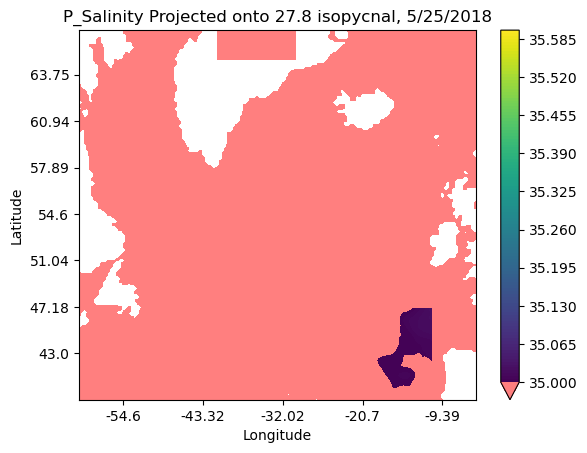

In [19]:
cmap = mpl.cm.viridis.copy() # Make a copy to avoid changing the original
cmap.set_under('red', alpha=.5)
plt.contourf(projection,np.arange(35,35.6, .005), cmap=cmap, extend='min')
plt.colorbar()
plt.title("P_Salinity Projected onto " + str(rho_goal) + " isopycnal, 5/25/2018")
plt.yticks(np.arange(25,200, 25), np.trunc(ds_t4.nav_lat_grid_T.values[275:450, 150][::25] * 100) / 100)
plt.xticks(np.arange(25,225, 45), np.trunc(ds_t4.nav_lon_grid_T.values[250, 175:375][::45] * 100) / 100)
plt.ylabel('Latitude')
plt.xlabel('Longitude')

In [ ]:
np.min(low)